# Optimal Stopping и хеджирование: отчёт по экспериментам

Этот ноутбук оформляет проделанную работу в папке $28-03-26$ в формате, удобном для диплома:

- вводная часть про американские опционы и задачу оптимальной остановки;
- обзор алгоритмов $LSM$, $NLSM$, $RLSM$ (по статье *Optimal Stopping via Randomized Neural Networks*);
- методика расчёта дискретного дельта-хеджа;
- результаты экспериментов (таблицы + графики);
- анализ и выводы для дальнейшей работы.

> Данные и графики читаются из артефактов в $28-03-26/output/$.

## 1. Вводная: американские опционы и оптимальная остановка

Американский опцион можно исполнить в любой момент до погашения, поэтому задача оценки цены формулируется как **optimal stopping**.

В дискретном времени (Bermudan-аппроксимация) при датах $0, 1, ..., N$:

- payoff в момент $n$: $g(X_n)$;
- continuation value: $c_n(X_n) = E[alpha * U_{n+1} | X_n]$;
- Snell envelope:

$
U_n = \max\left(g(X_n),\; E[\alpha U_{n+1} | X_n]\right).
$

Именно аппроксимация $c_n$ на каждом шаге назад определяет качество цены и последующего хеджа.

### Почему это важно для диплома

Ошибка в цене — это не весь риск. На практике важнее, насколько хорошо стратегия дельта-хеджа реплицирует обязательство по опциону вдоль траектории, особенно в хвостах распределения.

## 2. Алгоритмы: LSM, NLSM, RLSM

Опираемся на статью $Optimal-Stopping-Via-Randomized-NN.pdf$ (Herrera et al.):

- **LSM (Longstaff–Schwartz)**: continuation аппроксимируется линейной регрессией на базисных функциях.
- **NLSM**: continuation аппроксимируется нейросетью, параметры обучаются градиентно.
- **RLSM (Randomized LSM)**: скрытые слои фиксируются случайно, обучается только последний слой (линейная регрессия).

### Ключевая идея статьи

Randomized NN сводит нелинейную задачу оптимизации к выпуклой задаче линейной регрессии на случайных признаках. Это дает:

1. вычислительную стабильность;
2. более быстрый фит в больших размерностях;
3. при хорошей настройке — сопоставимое качество цены.

В текущем ноутбуке показываем не только цены, но и риск хеджа (VaR/CVaR), что для практики важнее.

In [ ]:
from pathlib import Path
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

BASE = Path("/home/kulikoval/mmkorshunova/Optimal-Stop-Problem/28-03-26")
OUT = BASE / "output"

prices_bs = pd.read_csv(OUT / "report_prices_bs.csv")
prices_heston = pd.read_csv(OUT / "report_prices_heston.csv")
hedge = pd.read_csv(OUT / "report_hedge_summary.csv")
sweep = pd.read_csv(OUT / "report_vol_sweep.csv")

with open(OUT / "report_hedge_risk.json", "r", encoding="utf-8") as f:
    hedge_risk_json = json.load(f)

print("Loaded:")
print("  prices_bs:", prices_bs.shape)
print("  prices_heston:", prices_heston.shape)
print("  hedge:", hedge.shape)
print("  sweep:", sweep.shape)

Loaded:
  prices_bs: (3, 6)
  prices_heston: (3, 6)
  hedge: (3, 9)
  sweep: (6, 5)


## 3. Конфигурация экспериментов

### Базовый сценарий (Black–Scholes)

- опцион: американский $Put1Dim$;
- $S_0=100, K=100, T=1, r=0.05, sigma=0.3$;
- 36 дискретных шагов;
- обучение: 12000 путей;
- тест хеджа: 2500 путей;
- для NLSM: hidden=28, epochs=22.

### Дополнительно

- Heston-сценарий для сравнения цен;
- sweep по волатильности $\sigma \; \in \;{0.2, 0.3, 0.4}$ для анализа чувствительности CVaR.

In [ ]:
prices_bs

,experiment,algo,model,price,time_s,path_gen_s
0,bs_main,LSM,BlackScholes,9.862460,0.13,0.0425
1,bs_main,NLSM,BlackScholes,8.459137,7.67,0.0790
2,bs_main,RLSM,BlackScholes,9.766693,2.48,0.0409


In [ ]:
prices_heston

,experiment,algo,model,price,time_s,path_gen_s
0,heston_main,LSM,Heston,9.874613,6.63,6.5952
1,heston_main,NLSM,Heston,3.837204,8.83,6.4646
2,heston_main,RLSM,Heston,9.663919,7.88,6.2238


Почему разные цены у LSM/NLSM/RLSM:

LSM и RLSM близки (и в BS, и в Heston)
Оба метода дают достаточно стабильную регрессию continuation в этой постановке, отсюда близкие оценки (~9.7–9.9).

NLSM заметно ниже (8.46 в BS и особенно 3.84 в Heston)
Основные причины:

сеть обучается на ITM-сэмплах (их может быть мало/шумно на шагах),
чувствительность к гиперпараметрам (hidden, epochs, сиды),
для Heston в вашем отчёте прямо отмечено: регрессия делается в упрощённом 1D-виде (без полного использования фактора дисперсии в признаках), из-за этого нейросеть может сильнее смещать continuation вниз.


* experiment  
Имя серии запуска (просто метка).
bs_main и heston_main задаются явно в run_report_pipeline.py.

* algo   
Алгоритм оценки continuation value в backward induction:

LSM — полиномиальная регрессия,
NLSM — нейросеть,
RLSM — random features + линейная регрессия последнего слоя.

* model. 
Стохастическая модель цены актива:

BlackScholes или
Heston.

* price. 
Оценка цены американского пута на t=0.
В коде это bundle.price_terminal_discounted, считается как max(immediate at t0, continuation estimate).

* time_s      
Общее время прогона алгоритма для строки (сек).
Включает и генерацию путей, и backward-fit.

* path_gen_s   
Только время генерации MC-траекторий внутри fit_backward_snapshots.

## 4. Графики по цене опциона

Ниже — готовые графики из $output/$.

- На Black–Scholes цены $LSM$ и $RLSM$ близки, $NLSM$ в текущей настройке занижен.
- На Heston наблюдается тот же эффект: $NLSM$ заметно ниже $LSM/RLSM$.

Это означает, что нейросетевой подход чувствителен к настройкам обучения (эпохи, архитектура, выбор train ITM, регуляризация), и без тюнинга может давать смещенную value-функцию.

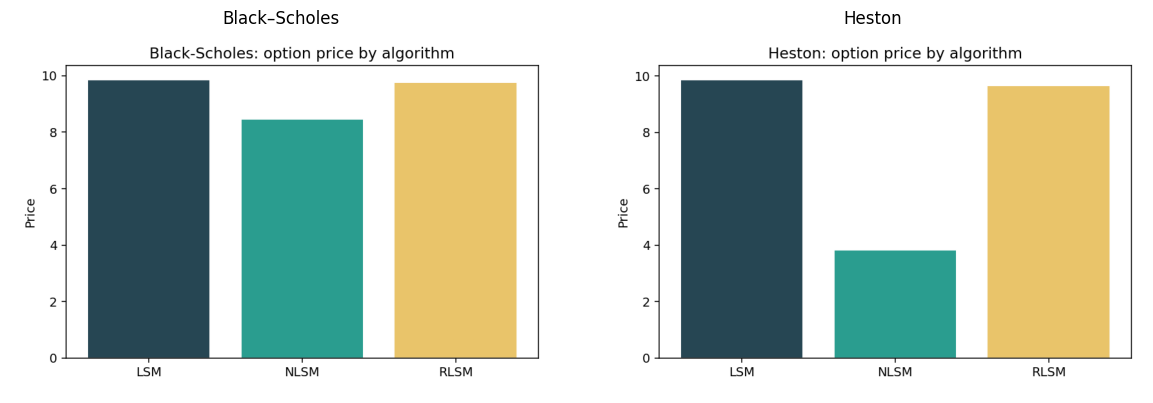

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

img1 = mpimg.imread(OUT / "report_prices_bs_bar.png")
ax[0].imshow(img1)
ax[0].axis("off")
ax[0].set_title("Black–Scholes")

img2 = mpimg.imread(OUT / "report_prices_heston_bar.png")
ax[1].imshow(img2)
ax[1].axis("off")
ax[1].set_title("Heston")

plt.tight_layout()
plt.show()

## 5. Как считались хеджи (методика)

Используется дискретный self-financing дельта-хедж.

Обозначения:

- $V_i$ — модельная стоимость опциона в момент $t_i$;
- $\Delta_i = dV/dS$ (в проекте: центральная разность по $S$);
- $B_i$ — позиция в cash;
- $Phi_i = \Delta_i * S_i + B_i$ — стоимость хедж-портфеля.

Рекурсия на шаге:

$
\text{wealth\_pre}_{i+1} = \Delta_i S_{i+1} + B_i e^{r\Delta t},
$
$
B_{i+1} = \text{wealth\_pre}_{i+1} - \Delta_{i+1} S_{i+1},
$
$
\Phi_{i+1} = \Delta_{i+1} S_{i+1} + B_{i+1}.
$

### Метрика ошибки хеджа

На каждой траектории считался максимум дисконтированного shortfall:

$
L = \max_i e^{-rt_i}\max(0, V_i - \Phi_i).
$

По выборке траекторий строилось распределение $L$, затем считались $VaR95$ и $CVaR95$.

### Как это переносится на разные опционы

В коде payoff задается функцией $g(S)$:

- $Put1Dim$: $max(K-S, 0)$;
- $Call1Dim$: $max(S-K, 0)$;
- $MaxPut$: $max(K-max_j S_j, 0)$;
- $MaxCall$: $max(max_j S_j-K, 0)$;
- $BasketCall$: $max(mean_j S_j - K, 0)$.

Алгоритм хеджа тот же, меняется только:
1. функция intrinsic payoff;
2. размерность состояния (один актив или вектор активов);
3. способ расчёта $\Delta$ (градиент по каждому активу в многомерном случае).

In [ ]:
hedge

,suite,algo,price,fit_s,loss_mean,loss_p95,var95,cvar95,n_paths_hedge
0,bs_main,LSM,9.862460,0.16,3.886812,11.618425,11.632851,16.181183,2500
1,bs_main,NLSM,8.459137,4.28,17.809595,31.448681,31.452191,37.246572,2500
2,bs_main,RLSM,9.766693,1.95,21.393057,62.728669,62.787986,78.446719,2500


price    
Цена опциона, полученная этим алгоритмом на обучении.

fit_s    
Время обучения/подгонки модели continuation (сек).

loss_mean  
Среднее по траекториям максимального дисконтированного shortfall  
​

loss_p95  
95-й перцентиль этой же величины (почти хвост, но не условный).

var95  
VaR на 95% (по реализации в коде — квантили отсортированной выборки).

cvar95  
CVaR 95% — среднее в хвосте выше/на уровне VaR (tail-risk).

n_paths_hedge  
Число тестовых траекторий, по которым считалась статистика (2500).


По вашим числам:

LSM: mean 3.89, CVaR 16.18 (лучший профиль)
NLSM: mean 17.81, CVaR 37.25
RLSM: mean 21.39, CVaR 78.45 (самый тяжелый хвост)
Ключевая причина: в п.5 вы меряете не ошибку цены, а ошибку динамического хеджа.
Даже если price близка, tail-risk может сильно отличаться.

Почему это происходит:

Хедж чувствителен к Δ, а Δ берется численно через finite-difference от аппроксимированного V(S,t); если поверхность V «неровная», в хвостах shortfall резко растет.
NLSM/RLSM обучаются на задачу continuation (MSE/регрессия), а не напрямую на риск хеджа → локально по Δ может быть нестабильно.
RLSM с random features может давать «шипы» в Δ на части состояний → редкие, но очень большие промахи, отсюда огромный cvar95.
LSM в 1D часто дает более гладкую и стабильную форму continuation/дельты, поэтому хвост потерь ниже.


## 6. Графики хедж-риска и объяснение

### 6.1. VaR95 / CVaR95

На графике ниже:

- $VaR95$ — 95%-квантиль потерь;
- $CVaR95$ — средняя потеря в хвосте выше VaR.

Для риск-менеджмента $CVaR$ важнее: показывает размер потерь в плохих сценариях.

В текущих прогонах:
- минимальный tail-risk у LSM;
- NLSM выше LSM;
- RLSM самый тяжелый хвост.

Это прямо поддерживает тезис диплома про необходимость смотреть именно **распределение ошибки хеджа**, а не только среднюю цену опциона.

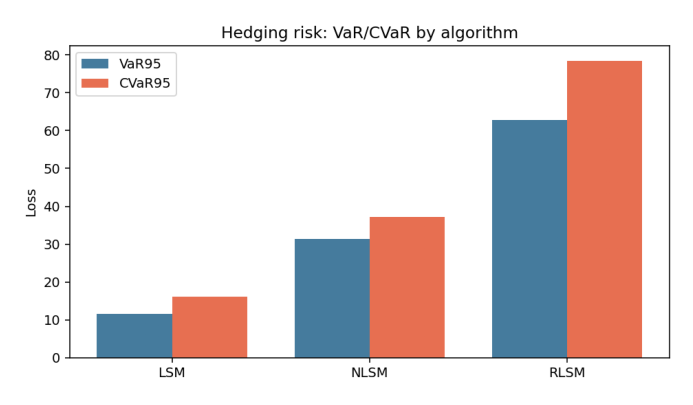

In [ ]:
img = mpimg.imread(OUT / "report_hedge_var_cvar_bar.png")
plt.figure(figsize=(9,5))
plt.imshow(img)
plt.axis("off")
plt.show()

### 6.2. Формы распределений ошибки (по алгоритмам)

Ниже — гистограммы ошибок хеджа для каждого алгоритма.

Интерпретация:
- смещение вправо = выше типичная ошибка;
- длинный правый хвост = выше риск экстремальных потерь.

Именно такие графики полезны для расчёта буфера капитала (резерва) при продаже опциона.

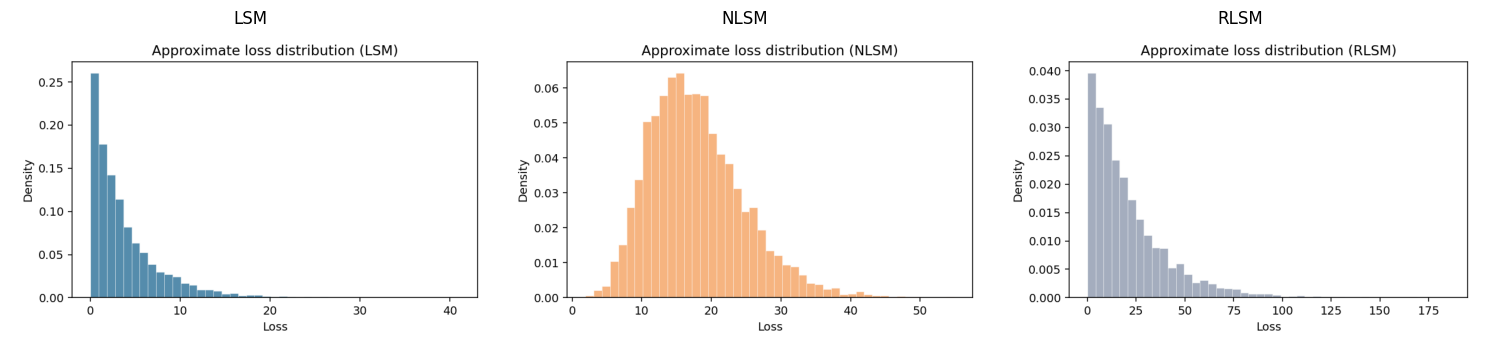

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for i, algo in enumerate(["LSM", "NLSM", "RLSM"]):
    img = mpimg.imread(OUT / f"report_hedge_hist_bs_main_{algo}.png")
    ax[i].imshow(img)
    ax[i].axis("off")
    ax[i].set_title(algo)

plt.tight_layout()
plt.show()

1. Считается вектор потерь $m_{model}$ по 2500 траекториям.  
   Один элемент =  
   $$
   L_j = \max_i e^{-rt_i}\max(0,\;V_i^{model}-\Phi_i)
   $$
   (максимальный дисконтированный shortfall на траектории $j$).

## Что по осям

- **Ось X (Потери)** — величина $L_j$ (в деньгах, не в процентах), всегда $>=0$.
- **Ось Y (Плотность)** — не число траекторий, а нормированная плотность ($density=True$), площадь под гистограммой примерно равна 1.
- Пунктирная вертикаль — $VaR95$ (порог 95%-квантили).

## Почему графики имеют именно такой вид

1. Метрика — это **максимум по времени** → распределение становится правосторонним (длинный хвост вправо).
2. Есть $max(0, ...)$ → отрицательных значений нет, вся масса только справа от нуля.
3. Разница между алгоритмами — из-за качества и гладкости $V$ и особенно $\Delta$:
   - $LSM$: компактнее, хвост короче ($VaR/CVaR$ ниже).
   - $NLSM$: сдвиг вправо (типичные потери выше).
   - $RLSM$: самый тяжелый хвост (редкие, но очень большие shortfall).

По числам это видно:
- LSM: $median ~2.89$, $p95 ~11.62$, $max ~41.55$
- NLSM: $median ~16.09$, $p95 ~31.45$, $max ~60.93$
- RLSM: $median ~15.46$, $p95 ~62.73$, $max ~134.90$


### 6.3. Чувствительность риска хеджа к волатильности

График показывает, как меняется $CVaR95$ при росте $sigma$.

В этом эксперименте:
- у LSM риск растёт умеренно;
- у NLSM риск существенно выше на всей сетке $sigma$.

Вывод: для нейросетевых алгоритмов нужен отдельный этап калибровки под **hedge-risk objective**, иначе tail-risk может быть существенно выше классического baseline.

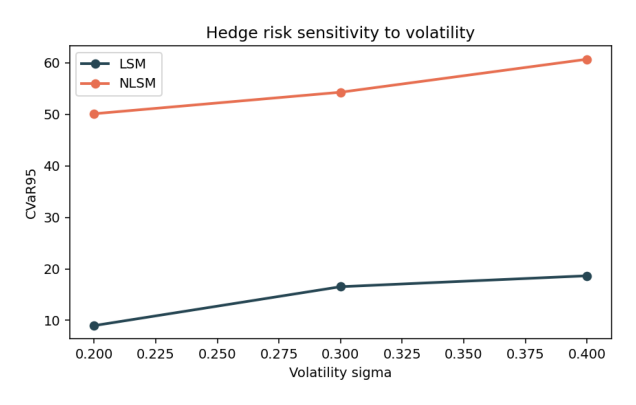

,volatility,algo,price,hedge_loss_mean,cvar95
0,0.2,LSM,6.039178,2.616243,8.989498
1,0.2,NLSM,4.144546,33.046521,50.127927
2,0.3,LSM,9.988810,4.132068,16.537898
3,0.3,NLSM,7.068956,34.349893,54.302389
4,0.4,LSM,13.685014,5.414484,18.659004
5,0.4,NLSM,6.201779,30.478181,60.707150


In [ ]:
img = mpimg.imread(OUT / "report_sweep_cvar.png")
plt.figure(figsize=(9,5))
plt.imshow(img)
plt.axis("off")
plt.show()

sweep

## 7. Анализ результатов с точки зрения статьи

Сопоставление с идеями статьи:

1. **Pricing блок**:
   - статья показывает, что randomized-подходы дают сопоставимое качество и хорошую вычислительную эффективность;
   - в наших 1D настройках $RLSM ~ LSM$ по цене, $NLSM$ чувствителен к гиперпараметрам и в текущем запуске занижен.

2. **Hedging блок**:
   - статья также подчеркивает возможность вычислять Greeks и использовать методы для практических задач;
   - наш эксперимент расширяет фокус на распределение ошибки хеджа (VaR/CVaR), что хорошо ложится в дипломную новизну.

3. **Практический вывод**:
   - ориентироваться только на ошибку цены недостаточно;
   - для внедрения ML-модели в хедж нужно контролировать хвосты распределения ошибок.

### Рекомендация для формулировки дипломного результата

"Нейросетевые методы в задаче optimal stopping перспективны, но качество хеджирования определяется не только точностью цены, а также стабильностью и хвостовым риском ошибок репликации; это требует отдельной риск-ориентированной калибровки модели."

## 8. Выводы и дальнейшие шаги

### Что уже сделано

- реализован единый pipeline $LSM/NLSM/RLSM$;
- собраны таблицы по ценам и времени;
- добавлена полноценная оценка риска хеджа (VaR/CVaR, tail behavior);
- сделан stress-test по волатильности.

### Что делать дальше

1. Сохранять raw per-path массивы ошибок хеджа (не только summary).
2. Добавить интервальные оценки (bootstrap CI) для VaR/CVaR.
3. Провести серию запусков по seed (устойчивость оценок).
4. Тюнить NLSM/RLSM именно под хедж-метрики (не только MSE continuation).
5. Добавить реальные данные (например, BTC) и out-of-sample backtest.

### Идеи по моделям для ML-хеджирования

- базовый стек для диплома: $LSM$, $NLSM$, $RLSM$;
- продвинутый baseline: Deep Hedging (policy-based);
- для path-dependent задач: LSTM/Transformer policy и/или continuation model.